# Machine Learning  Based Candidate Biomarkers for Chronic Kidney Disease Using Single-Cell Transcriptomic Data

## Load the dataset

In [ ]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the .h5ad file
adata = sc.read_h5ad('GSE211785_7_13_23_slide0_annotated_iPTsubclusters.h5ad')

# Basic inspection
print(adata)  # Shows shape: cells x genes
print(adata.obs.head())  # Cell metadata (e.g., clusters, sample info)
print(adata.var.head())  # Gene metadata
print(adata.uns.keys())  # Unstructured data (e.g., colors, dendrograms)

# Check for key annotations (e.g., disease vs. control)
if 'condition' in adata.obs.columns:  # Assuming columns like 'condition' or 'disease_status'
    print(adata.obs['condition'].value_counts())  # e.g., CKD vs. healthy

AnnData object with n_obs × n_vars = 558601 × 1001
    obs: 'nn_33131227.a09b.4d87.addf.d7bb907597e5_1_cluster_cluster_e1ad5c7b.3174.4ee9.bfbc.d6efb6833675_1', 'RNA_nbclust_41a5ffc1.6941.4e83.af9c.d661c9c543e5_1_clusters', 'RNA_nbclust_41a5ffc1.6941.4e83.af9c.d661c9c543e5_1_posterior_probability', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_negprobes', 'nFeature_negprobes', 'nCount_falsecode', 'nFeature_falsecode', 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.B', 'Max.B', 'Mean.CK8.18', 'Max.CK8.18', 'Mean.Membrane', 'Max.Membrane', 'Mean.R', 'Max.R', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'assay_type', 'slide_ID_numeric', 'Run_Tissue_name', 'Panel', 'cell_ID', 'x_FOV_px', 'y_FOV_px', 'x_slide_mm', 'y_slide_mm', 'propNegative', 'complexity', 'errorCtEstimate', 'percOfDataFromError', 'qcFlagsRNACounts', 'qcFlagsCellCounts', 'qcFlagsCellPropNeg', 'qcFlagsCellComplex', 'qcFlagsCellArea', 'median_negprobes', 'negprobes_quantile_0.9', 'median_RNA', 'RNA_quantile_0.9', 'nCell'

### View all columns in adata.obs

In [ ]:
print("All columns in adata.obs:")
print(adata.obs.columns.tolist())

print("\n--- Checking common grouping columns ---")
for col in adata.obs.columns:
    if adata.obs[col].nunique() < 20:   # only show columns that are useful for grouping
        print(f"{col} → {adata.obs[col].value_counts().to_dict()}")

All columns in adata.obs:
['nn_33131227.a09b.4d87.addf.d7bb907597e5_1_cluster_cluster_e1ad5c7b.3174.4ee9.bfbc.d6efb6833675_1', 'RNA_nbclust_41a5ffc1.6941.4e83.af9c.d661c9c543e5_1_clusters', 'RNA_nbclust_41a5ffc1.6941.4e83.af9c.d661c9c543e5_1_posterior_probability', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_negprobes', 'nFeature_negprobes', 'nCount_falsecode', 'nFeature_falsecode', 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.B', 'Max.B', 'Mean.CK8.18', 'Max.CK8.18', 'Mean.Membrane', 'Max.Membrane', 'Mean.R', 'Max.R', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'assay_type', 'slide_ID_numeric', 'Run_Tissue_name', 'Panel', 'cell_ID', 'x_FOV_px', 'y_FOV_px', 'x_slide_mm', 'y_slide_mm', 'propNegative', 'complexity', 'errorCtEstimate', 'percOfDataFromError', 'qcFlagsRNACounts', 'qcFlagsCellCounts', 'qcFlagsCellPropNeg', 'qcFlagsCellComplex', 'qcFlagsCellArea', 'median_negprobes', 'negprobes_quantile_0.9', 'median_RNA', 'RNA_quantile_0.9', 'nCell', 'nCount', 'nCountPerCell', 'nFe

## Random Forest

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import scanpy as sc

# Prepare data: Use .X (normalized/logged expression) or .layers['counts'] if raw preferred
# But for ML, normalized is often better; assume .X is preprocessed

# Labels: 'type' -> map to 0/1 for binary classification (Healthy=0, Disease=1)
adata.obs['label'] = adata.obs['type'].map({'Healthy': 0, 'Disease': 1})

# Features: Use all genes, or subset to highly variable if computed
if 'highly_variable' in adata.var.columns:
    X = adata[:, adata.var.highly_variable].X.toarray() if hasattr(adata.X, 'toarray') else adata[:, adata.var.highly_variable].X
    genes = adata[:, adata.var.highly_variable].var_names
else:
    X = adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X
    genes = adata.var_names

y = adata.obs['label'].values

print(f"Features shape: {X.shape}, Labels shape: {y.shape}")
print(f"Class balance: Healthy={np.sum(y==0)}, Disease={np.sum(y==1)}")

Features shape: (558601, 1001), Labels shape: (558601,)
Class balance: Healthy=283641, Disease=274960


Train shape: (418950, 1001), Test shape: (139651, 1001)

Model Performance on Test Set:
Accuracy: 0.832

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.87      0.79      0.83     70911
     Disease       0.80      0.88      0.84     68740

    accuracy                           0.83    139651
   macro avg       0.83      0.83      0.83    139651
weighted avg       0.84      0.83      0.83    139651


Top 20 Biomarkers (by Random Forest importance):
        gene  importance
0     RPS4Y1    0.108014
1      VEGFA    0.057287
2        EGF    0.038814
3      RPL37    0.037392
4      CALB1    0.032049
5      NEAT1    0.027979
6      CRYAB    0.027246
7      RPL34    0.026339
8       TPT1    0.025979
9   HSPA1A/B    0.024734
10    IGFBP7    0.022409
11      XIST    0.021136
12     ZFP36    0.017286
13      CD24    0.016716
14     DUSP1    0.016267
15     RPL21    0.014684
16    MALAT1    0.014152
17       MGP    0.014061
18      PSAP    0.01

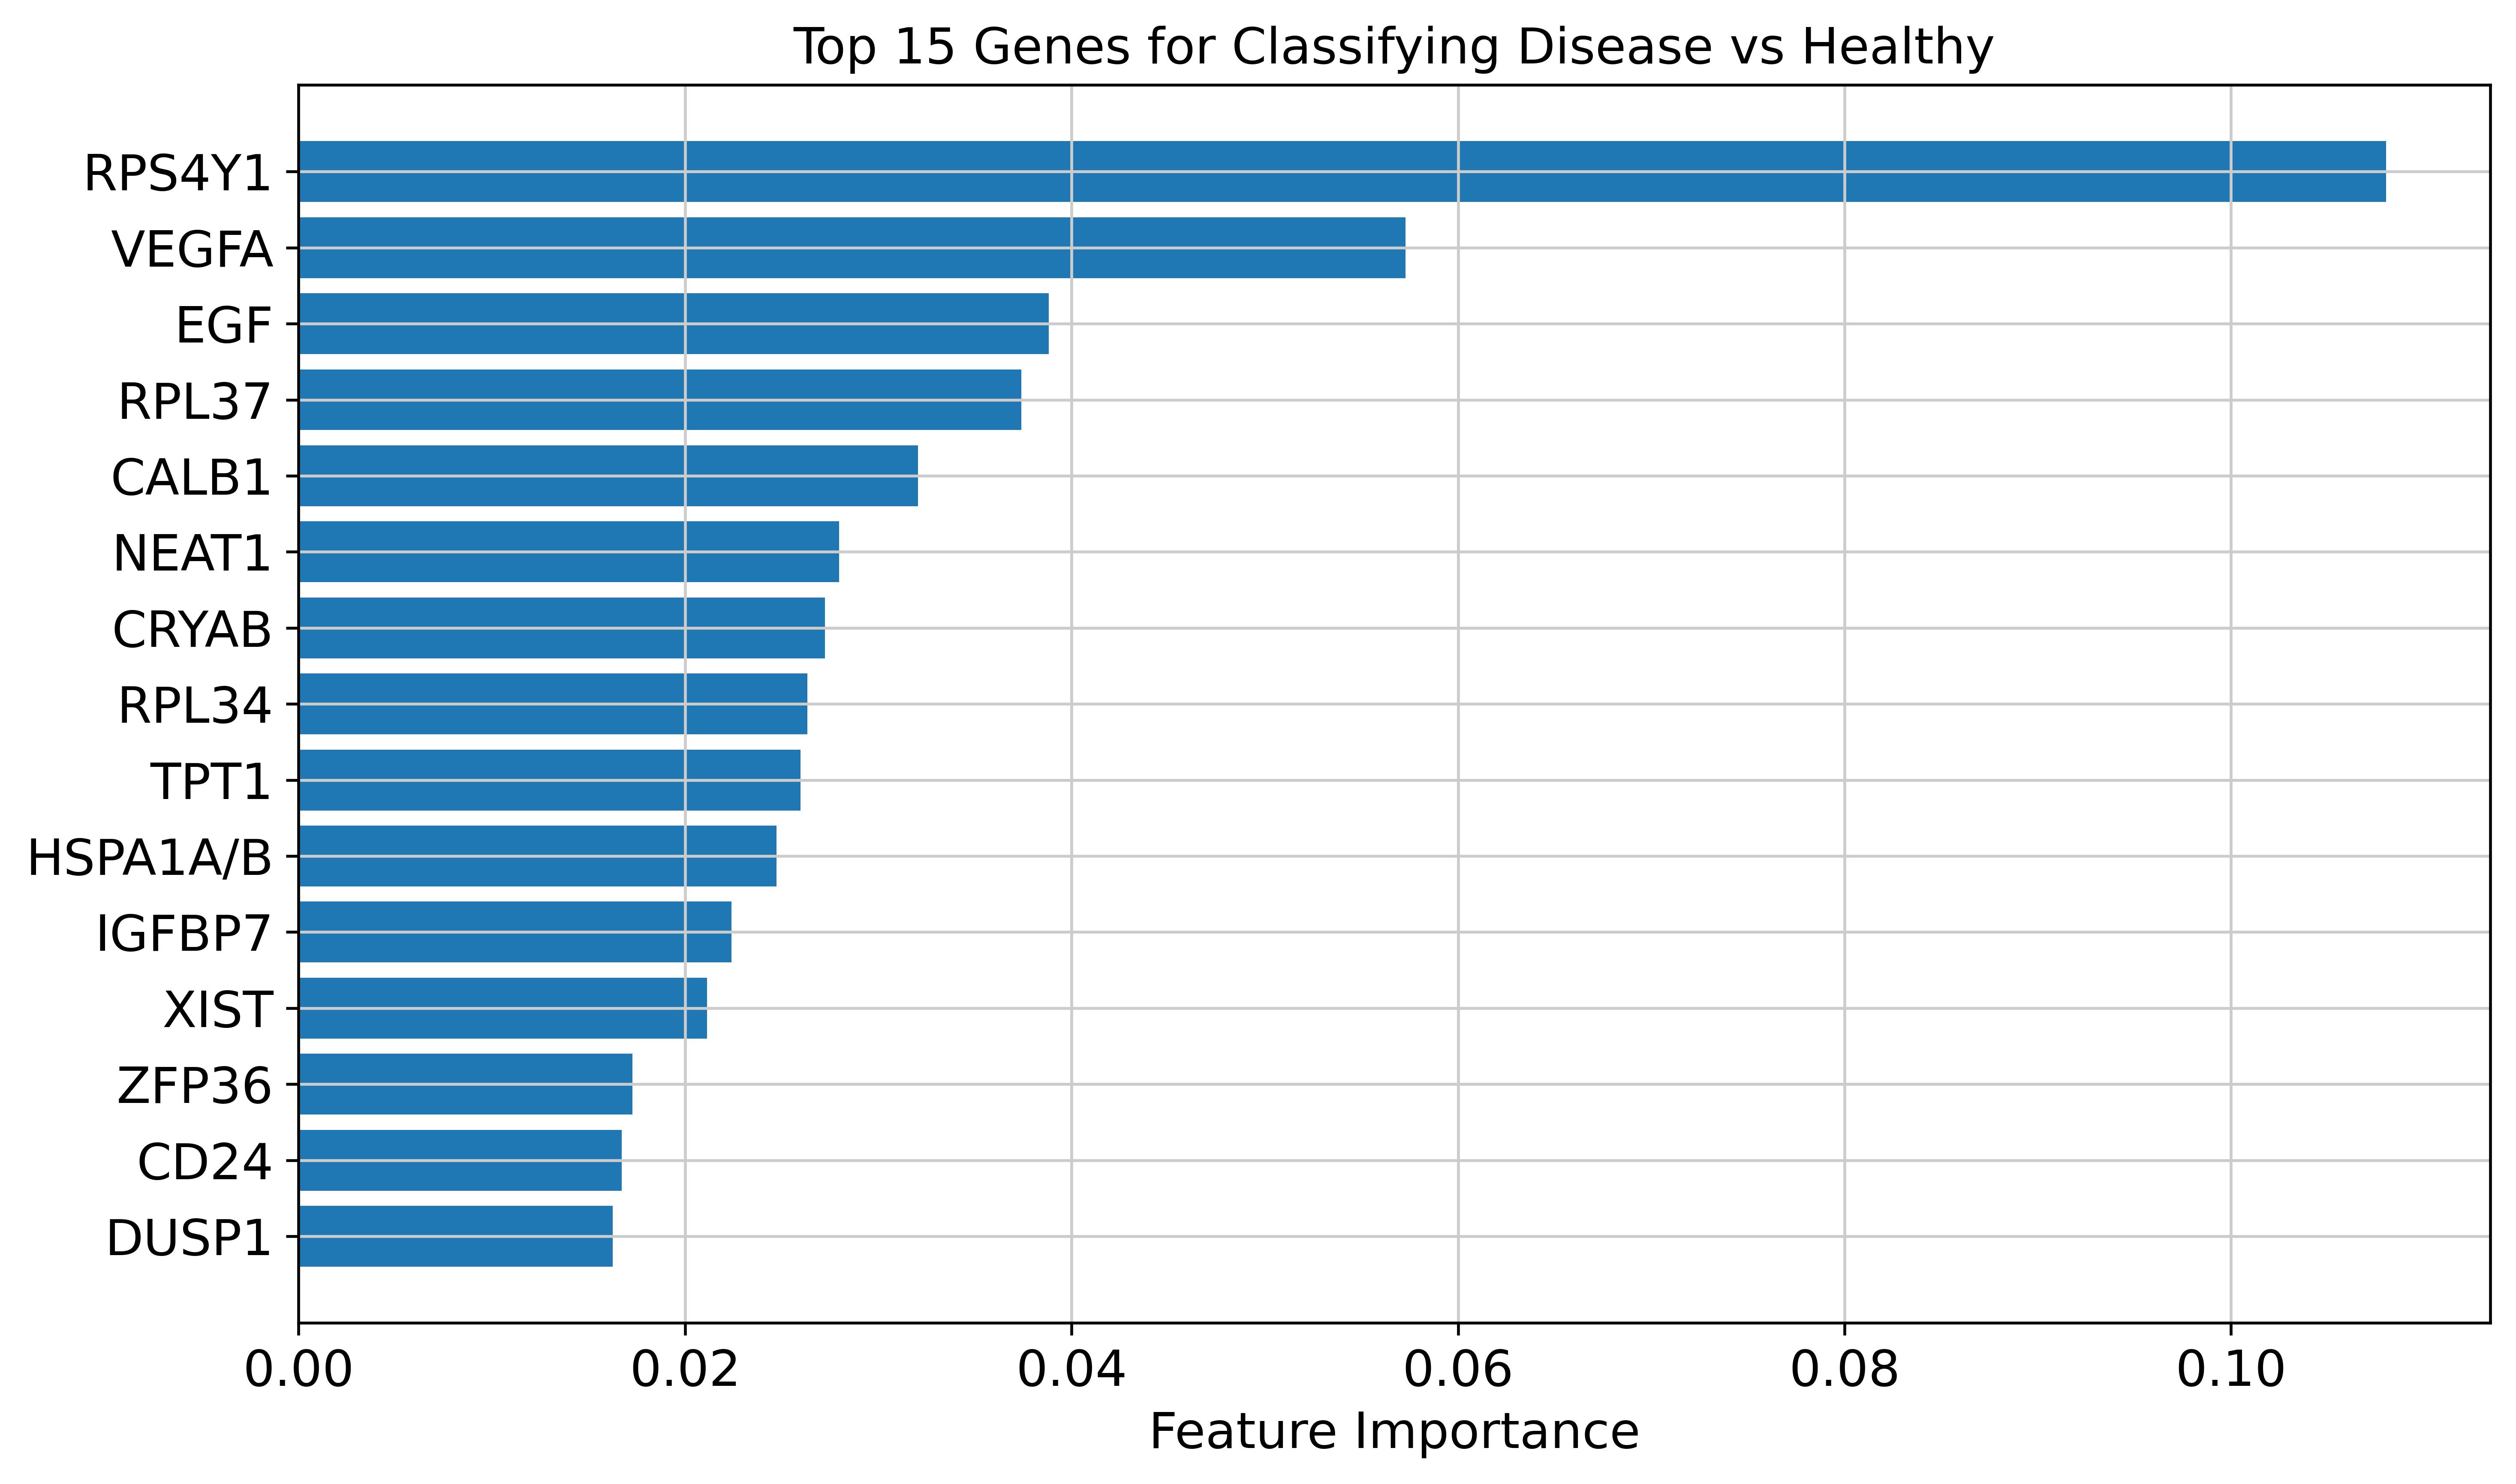

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt

# Split into train/test (stratify to keep class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,          # 25% for testing
    random_state=42,
    stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# Train Random Forest
model = RandomForestClassifier(
    n_estimators=200,      # number of trees — 200 is good balance speed/quality
    max_depth=12,          # prevent overfitting
    min_samples_split=5,
    random_state=42,
    n_jobs=-1              # use all CPU cores
)

model.fit(X_train, y_train)

# Predict & evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Performance on Test Set:")
print(f"Accuracy: {accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Disease']))

# Get feature importances (this is your biomarker ranking)
importances = model.feature_importances_
feature_names = genes  # from previous block

# Create sorted DataFrame
biomarker_df = pd.DataFrame({
    'gene': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Show top 20 biomarkers
print("\nTop 20 Biomarkers (by Random Forest importance):")
print(biomarker_df.head(20))

# Save to CSV for your thesis
biomarker_df.to_csv('rf_biomarkers_disease_vs_healthy.csv', index=False)
print("\nSaved full ranking to: rf_biomarkers_disease_vs_healthy.csv")

# Quick bar plot of top 15
plt.figure(figsize=(10, 6))
plt.barh(biomarker_df['gene'].head(15), biomarker_df['importance'].head(15))
plt.gca().invert_yaxis()  # highest on top
plt.xlabel('Feature Importance')
plt.title('Top 15 Genes for Classifying Disease vs Healthy')
plt.tight_layout()
plt.show()